<a href="https://colab.research.google.com/github/shivkushwaha04/student-placement-prediction/blob/main/placement_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv('/content/sample_data/placement.csv')

In [ ]:
df.head()   #to take overview


,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
df.shape    #(100, 4)

(100, 4)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [7]:
df=df.iloc[:,1:]
# Take all rows, but remove the first column of the DataFrame.

In [8]:
df.head()
#cgpa and iq are independent variables
# placement is dependent variable

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [9]:
# Steps

# 0. Preprocess + EDA (Exploratory Data Analysis) + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values (distances between x and y)
# 3. Train test split (out of 100 we will train throgh 90 only so that we can check from 10 values after making the model (for evaluation))
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [10]:
import matplotlib.pyplot as plt

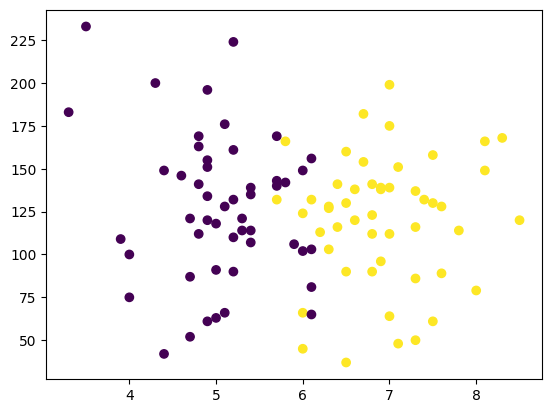

In [11]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])
#c=color, yellow--> placement done
# through logistic regression

In [12]:
x=df.iloc[:,0:2]  # 0 and 1 column
y=df.iloc[:,-1]  #last column

In [13]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [14]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [15]:
y.shape


(100,)

In [16]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.1)
# train_test_split(independent, dependent, test_size=0.1)
# from starting 10, now are the t
# first 10 --> training set after x of test set after, y of training set and then y of test set

In [17]:
x_train

,cgpa,iq
49,5.4,135.0
17,3.3,183.0
75,4.8,169.0
59,4.8,112.0
32,7.0,139.0
...,...,...
60,6.9,139.0
61,7.3,137.0
89,4.9,151.0
30,7.6,128.0


In [18]:
x_test

,cgpa,iq
91,7.5,158.0
64,7.0,64.0
44,7.5,61.0
82,6.5,37.0
77,7.3,50.0
28,5.2,90.0
1,5.9,106.0
86,5.1,128.0
94,4.7,52.0
58,8.0,79.0


In [19]:
y_train

,placement
49,0
17,0
75,0
59,0
32,1
...,...
60,1
61,1
89,0
30,1


In [20]:
y_test

,placement
91,1
64,1
44,1
82,1
77,1
28,0
1,0
86,0
94,0
58,1


In [21]:
from sklearn.preprocessing import StandardScaler
#to scale it from -1 to 1

In [22]:
scaler=StandardScaler()

In [23]:
x_train=scaler.fit_transform(x_train)

In [24]:
x_train

array([[-0.47667636,  0.18325507],
       [-2.33807783,  1.46633755],
       [-1.00850535,  1.09210516],
       [-1.00850535, -0.43155529],
       [ 0.94153429,  0.29017861],
       [ 0.76425796, -0.13751555],
       [ 0.58698163, -0.21770821],
       [-1.09714352, -0.19097732],
       [-0.65395269,  0.87825808],
       [-1.71761067, -0.75232591],
       [ 0.85289613, -0.85924945],
       [-1.36305801, -2.30271724],
       [-0.65395269,  2.56230383],
       [ 1.20744879, -1.1265583 ],
       [-0.12212369,  1.0119125 ],
       [ 0.05515264, -2.22252458],
       [-0.83122902, -0.99290387],
       [-1.71761067, -1.42059803],
       [ 0.49834346, -1.01963476],
       [-1.00850535,  0.93171985],
       [-0.21076186,  1.09210516],
       [ 0.05515264, -1.661176  ],
       [-0.47667636, -0.37809352],
       [ 2.27110677, -0.21770821],
       [ 1.20744879, -0.32463175],
       [ 0.05515264, -0.11078467],
       [-0.91986718, -0.21770821],
       [-1.09714352, -1.09982741],
       [ 0.49834346,

In [25]:
x_test=scaler.transform(x_test)
#not fit again coz pattern our first code stands

In [26]:
x_test

array([[ 1.38472512,  0.79806542],
       [ 0.94153429, -1.71463777],
       [ 1.38472512, -1.79483042],
       [ 0.49834346, -2.43637166],
       [ 1.20744879, -2.08887016],
       [-0.65395269, -1.01963476],
       [-0.03348553, -0.5919406 ],
       [-0.74259085, -0.00386113],
       [-1.09714352, -2.03540839],
       [ 1.82791595, -1.31367449]])

In [27]:
#to train the model
from sklearn.linear_model import LogisticRegression

In [28]:
clf=LogisticRegression()

In [29]:
#model training
clf.fit(x_train, y_train)

LogisticRegression()

In [30]:
# Evaluate the model
y_pred=clf.predict(x_test)

In [31]:
y_pred

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 1])

In [32]:
y_test

,placement
91,1
64,1
44,1
82,1
77,1
28,0
1,0
86,0
94,0
58,1


In [33]:
from sklearn.metrics import accuracy_score

In [34]:
accuracy_score(y_test, y_pred)
# in 10 it is giving 8 right prediction

1.0

In [35]:
# Search (rasbt.github) mlextend plot decisiion library
# link: https://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/
from mlxtend.plotting import plot_decision_regions


<Axes: >

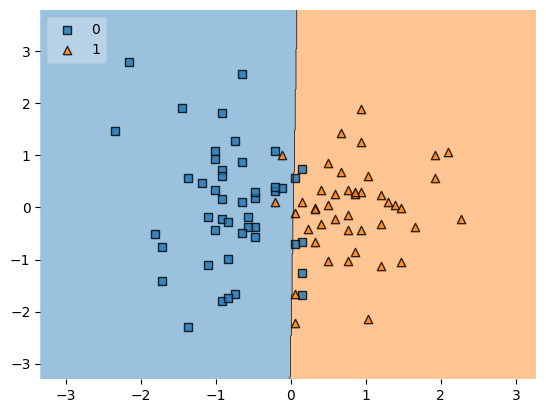

In [36]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)
# x_train is already a scalar but y_train we have to takes only values

In [37]:
import pickle

In [38]:
pickle.dump(clf, open('model.pkl', 'wb')) # wb: write binary